# Demo

A demostration script for the ECLYPSE network simulator extension.

This script validates the implementation of the M/M/1 queuing model,
physical link parameters, and routing tables by simulating a "bottleneck"
scenario.
It sets up a topology (Sensor → Gateway → Cloud), defines traffic flows,
and measures the end-to-end packet delays to demonstrate the emergence of
queuing congestion.

In [14]:
import time
from eclypse.remote.service import Service
from mm1_infrastructure import MM1Infrastructure
from network_application import NetworkAwareApplication
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

**DemoService** is a placeholder service to represent application endpoints (e.g. Sensors, Cloud).

In this network-focused simulation, services do not perform internal computation (CPU/RAM logic). They serve as anchors in the application graph to define the source and destination of network flows.

In [15]:
class DemoService(Service):
    def __init__(self, name):
        super().__init__(name)
        self.step_callback = None

    async def step(self):
        pass

The following script orchestrates the bottleneck simulation scenario.

Steps performed:
1. **Infrastructure setup**: Creates a 3-node network (Sensor, Gateway, Cloud). Configures a fast LAN link (100 mbps) and a slow WAN link (10 Mbps) to create a bottleneck.
2. **Application setup**: Defines an application with a flow from Sensor to Cloud.
3. **Routing**: Simulates OSPF convergence to populate routing tables.
4. **Simulation**: Sends a burst of packets and tracks their travel time hop-by-hop.
5. **Analysis**: Prints a table showing start times, arrival times, and queuing delays.

**Service Time (The Speed Limit)**
We look at the physical limitations of the "Bottleneck" link.
- **The Constraints**: The link is limited to **10 Mbps** (10 million bits per second). Each packet we send is a fixed size of 1500 Bytes (which is $1500 \times 8 = 12000$ bits).
- **The Calculation**: To push one single packet onto the wire, the router requires a specific amount of time.

$Time = \frac{12000 \: bits}{10000000 \: bits/sec} = 0.0012 \: seconds = 1.2 \: ms$

This means that once the Gateway starts transmitting a packet, it is physically "busy" for the next **1,2 ms**. It cannot touch another packet during this window.

**Arrival Rate (The Traffic Jam)**
We look at how the application is creating work.
- **The input**: the `inter_arrival_time` is configured to **0.0005** seconds (0.5 ms).
- **The Rate**: This implies we are effectively trying to push data at a rate of 24 Mbps (12000 bits/0.0005 s).
- **The Conflict**: We are asking the router to do a job every 0.5 ms, but the router takes 1.2 ms to finish that job.

**Accumulating "Debt"**
This mismatch creates a guaranteed growing backlog. So for every single packet that arrives, the router falls further behind.

$Deficit \, per \, packet = Service \, Time (1.2 \, ms) - Arrival \, time (0.5 \,  ms) = 0.7 \, ms$

So we predict every time a new packet arrives, it will have to wait **0.7 ms longer** than the packet before it. This isn't random noise; it is a structural, linear accumulation of delay.

**Theoretical Calculation for the 50th Packet**
Based on this linear accumulation model, we can estimate the **Queuing Delay ($W_q$) for the N-th packet. The 50th packet ($N = 50$) finds 49 packet ahead of it that have contributed to the creation of the queue.

$W_{q,50} \approx (N-1) \times Deficit$

$W_{q,50} \approx 49 \times 0.7 \: ms = 34.3 \: ms$

To this waiting delay, we must add its own service time (1.2 ms) and propagation delay (negligible in this context), bringing the theoretical Total Delay ($T_{tot}) to:

$T_{tot,50} = W_{q,50} + T_s \approx 34.3 + 1.2 = 35.5 \: ms$


In [16]:
print("[Setup] Simulation configuration...")
infra = MM1Infrastructure("DemoNet")
infra.add_node("Sensor")
infra.add_node("Gateway")
infra.add_node("Cloud")
infra.add_physical_link("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)
infra.add_physical_link("Gateway", "Cloud", bandwidth_mbps=10, length_km=50) # Bottleneck

# Add services to the application
app = NetworkAwareApplication("IoT_Video_Stream")
app.add_service(DemoService("Sensor"))
app.add_service(DemoService("Cloud"))

# STRESS TEST PARAMETERS
PACKET_SIZE = 1500       # 1500 Bytes
PACKETS_TO_SEND = 50     # 50 Packets

app.add_flow("Sensor", "Cloud", packet_size_bytes=PACKET_SIZE, packets_per_tick=PACKETS_TO_SEND)
print(f"    Configured flow: {PACKETS_TO_SEND} packets of {PACKET_SIZE} Byte")
print("\n Routing table setup (OSPF Simulation)")
infra.install_shortest_path_routes()

next_hop = infra.get_next_hop("Sensor", "Cloud")
print(f"    Check Routing Table: Sensor -> Cloud passes through '{next_hop}'? {'Yes' if next_hop == 'Gateway' else 'No'}")

# -------------------------------------------------------------------------
# Running the simulation with data collection
# -------------------------------------------------------------------------

# UPDATE: Extremely aggressive input rate
inter_arrival_time = 0.0005 # 0.5 ms


print(f"\n Starting burst transmission of {PACKETS_TO_SEND} packets...")
sim_data = []
base_time = 0.0

for i in range(1, PACKETS_TO_SEND + 1):
    send_time = base_time + (i * inter_arrival_time)

    # Run simulation
    result = infra.simulate_packet_routing("Sensor", "Cloud", PACKET_SIZE, send_time)

    # Safe calculations
    total_delay_ms = result['total_e2e_delay'] * 1000
    
    # Safe arrival calculation
    arrival_time = send_time + result['total_e2e_delay']

    gateway_queue_ms = 0.0
    for hop in result['hops']:
        if "Gateway->Cloud" in hop['hop']:
            gateway_queue_ms = hop['queue'] * 1000

    sim_data.append({
        "Packet_ID": i,
        "Start_Time_s": send_time,
        "Arrival_Time_s": arrival_time,
        "Total_Delay_ms": total_delay_ms,
        "Gateway_Queue_ms": gateway_queue_ms
    })

# --- DATAFRAME & ANALYSIS ---
df = pd.DataFrame(sim_data)

print("\n[5] Data Preview:")
df

[Setup] Simulation configuration...
Add edge flow Sensor->Cloud: 50 pkt/tick with packet size 1500 Bytes
    Configured flow: 50 packets of 1500 Byte

 Routing table setup (OSPF Simulation)
--- Configuration of Routing Tables (OSPF simulation) ---
Routing tables installed on all nodes.
    Check Routing Table: Sensor -> Cloud passes through 'Gateway'? Yes

 Starting burst transmission of 50 packets...

[5] Data Preview:


,Packet_ID,Start_Time_s,Arrival_Time_s,Total_Delay_ms,Gateway_Queue_ms
0,1,0.0005,0.000908,0.407802,0.000000
1,2,0.0010,0.001597,0.596698,0.000000
2,3,0.0015,0.003270,1.770039,0.000000
3,4,0.0020,0.003379,1.379182,0.747764
4,5,0.0025,0.003415,0.915482,0.558416
5,6,0.0030,0.004260,1.260180,0.130876
6,7,0.0035,0.004526,1.026210,0.501953
7,8,0.0040,0.005471,1.471006,0.145271
8,9,0.0045,0.006539,2.038776,0.686122
9,10,0.0050,0.006547,1.546600,1.084847


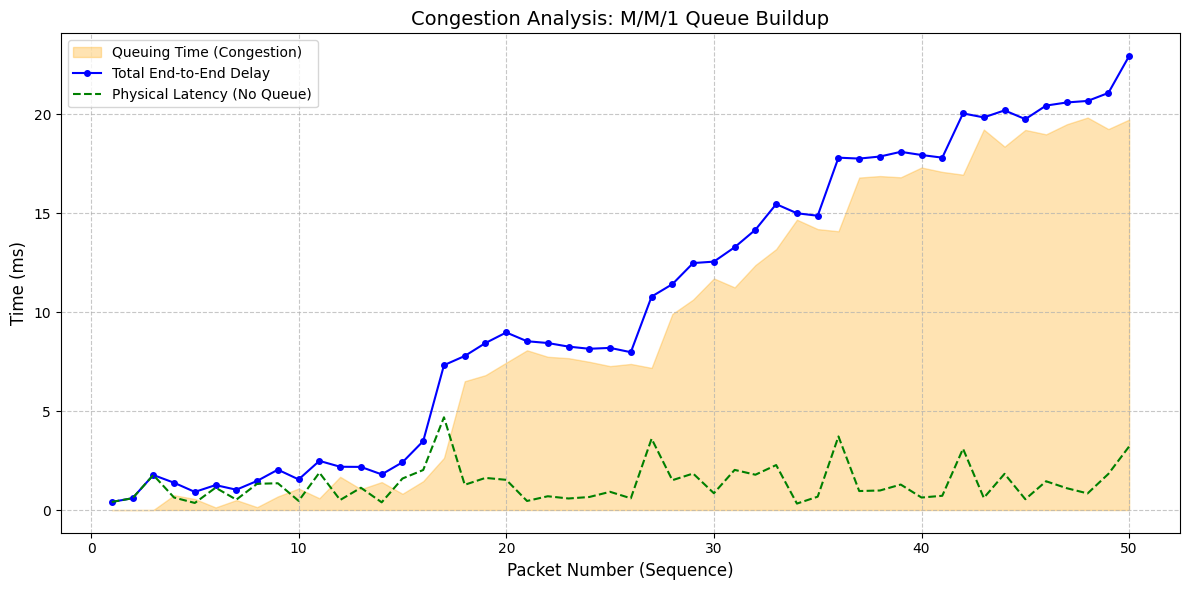

In [17]:
# --- PLOTTING ---
plt.figure(figsize=(12, 6))

# Queue area (filled to highlight the impact of congestion)
plt.fill_between(df["Packet_ID"], df["Gateway_Queue_ms"], color="orange", alpha=0.3, label="Queuing Time (Congestion)")

# Total delay line
plt.plot(df["Packet_ID"], df["Total_Delay_ms"], label="Total End-to-End Delay", color="blue", marker='o', markersize=4)

# Theoretical line (transmission + propagation only, without queue)
# This helps visualize how much the queue contributes to the total delay
physical_delay = df["Total_Delay_ms"] - df["Gateway_Queue_ms"]
plt.plot(df["Packet_ID"], physical_delay, label="Physical Latency (No Queue)", color="green", linestyle="--")

# Titles and Labels
plt.title("Congestion Analysis: M/M/1 Queue Buildup", fontsize=14)
plt.xlabel("Packet Number (Sequence)", fontsize=12)
plt.ylabel("Time (ms)", fontsize=12)

# Grid and Legend
plt.legend(loc="upper left")
plt.grid(True, which='both', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

### Jitter Analysis (Delay Variation)
Jitter shows how unstable the connection is. While the average delay grows, the jitter (instability) remains high due to the M/M/1 random service times, making the link unsuitable for real-time traffic.


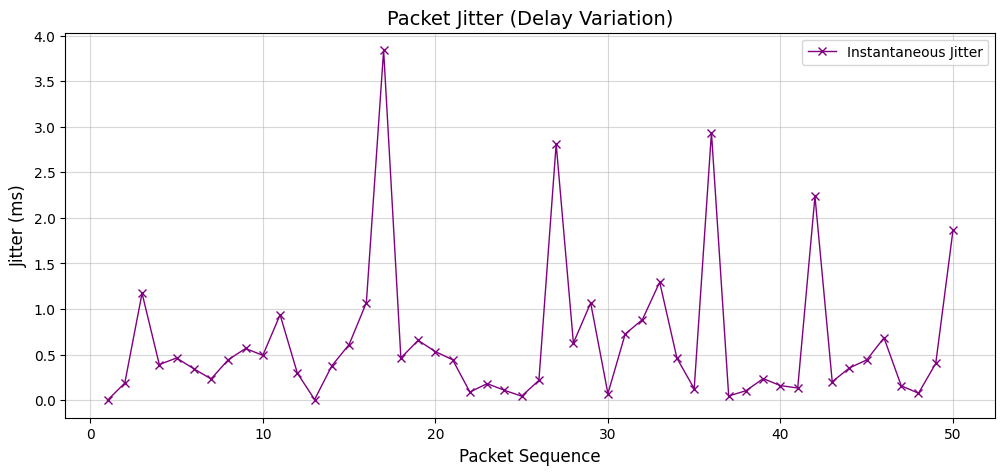

In [18]:
# Jitter is calculated as the absolute difference between consecutive delays
df['Jitter_ms'] = df['Total_Delay_ms'].diff().abs().fillna(0)

plt.figure(figsize=(12, 5))
plt.plot(df['Packet_ID'], df['Jitter_ms'], color='purple', marker='x', linestyle='-', linewidth=1, label="Instantaneous Jitter")
plt.title("Packet Jitter (Delay Variation)", fontsize=14)
plt.xlabel("Packet Sequence", fontsize=12)
plt.ylabel("Jitter (ms)", fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

### Throughput Saturation
We are pushing 24 Mbps into a 10 Mbps link. The graph demonstrates the policing effect of the bottleneck. Despite an Offered Load of 24 Mbps (Green Dotted Line), the measured throughput is mechanically capped at the physical link capacity of 10 Mbps (Red Dashed Line.) 


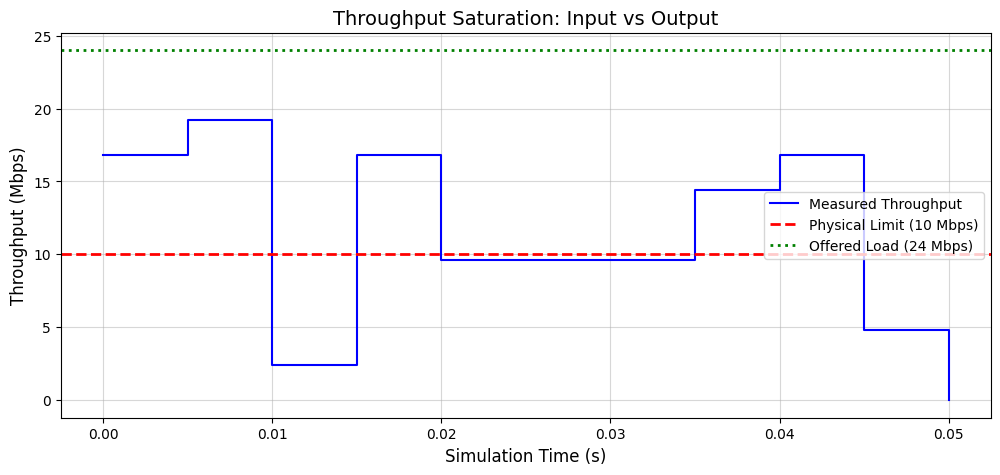

In [19]:
import numpy as np
# We calculate throughput by counting bits received in small time windows (e.g., 5ms)
window_size_s = 0.005 
max_time = df['Arrival_Time_s'].max()
time_bins = np.arange(0, max_time + window_size_s, window_size_s)

# Group packets into time bins based on Arrival Time
bins = np.digitize(df['Arrival_Time_s'], time_bins)
# Count packets per bin (excluding bin 0)
pkt_counts = np.bincount(bins, minlength=len(time_bins)+1)[1:len(time_bins)+1]

# Convert Count -> Mbps
# (Count * 1500 Bytes * 8 bits) / (Window Duration * 1,000,000 for Mbps)
throughput_mbps = (pkt_counts * 1500 * 8) / (window_size_s * 1_000_000)

plt.figure(figsize=(12, 5))
plt.plot(time_bins[:len(throughput_mbps)], throughput_mbps, label="Measured Throughput", color='blue', drawstyle='steps-post')

# Reference Lines
plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label="Physical Limit (10 Mbps)")
plt.axhline(y=24, color='green', linestyle=':', linewidth=2, label="Offered Load (24 Mbps)")

plt.title("Throughput Saturation: Input vs Output", fontsize=14)
plt.xlabel("Simulation Time (s)", fontsize=12)
plt.ylabel("Throughput (Mbps)", fontsize=12)
plt.legend(loc="right")
plt.grid(True, alpha=0.5)
plt.show()

### Queue Distribution
How likely is to find the queue empty vs full?
The distribution shifts heavily to the right, confirming that the 'steady state' of this saturated network involves a permanently non-empty queue.

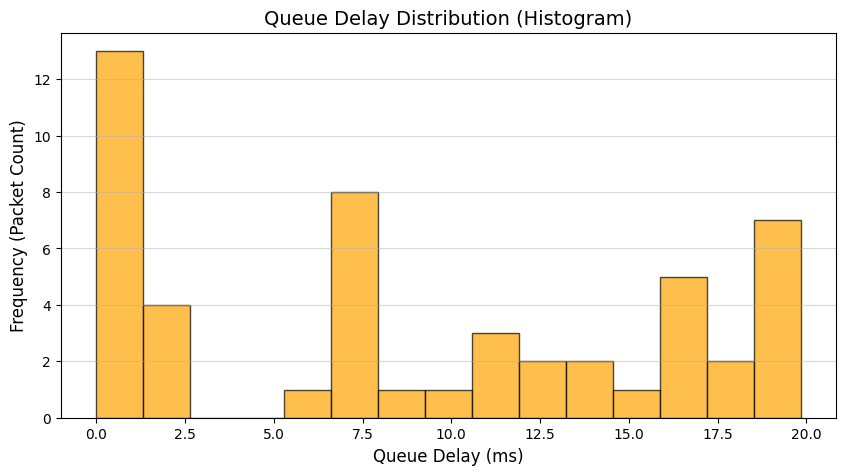

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(df['Gateway_Queue_ms'], bins=15, color='orange', edgecolor='black', alpha=0.7)

plt.title("Queue Delay Distribution (Histogram)", fontsize=14)
plt.xlabel("Queue Delay (ms)", fontsize=12)
plt.ylabel("Frequency (Packet Count)", fontsize=12)
plt.grid(True, axis='y', alpha=0.5)
plt.show()